## Generate Dataset

In [1]:
##create samples
import numpy as np
import pandas as pd

np.random.seed(42)

N_ROBOTS = 30
N_DAYS = 14
INTERVAL_MINUTES = 5

samples_per_day = 24 * 60 // INTERVAL_MINUTES
samples_per_robot = samples_per_day * N_DAYS

print("Samples per robot:", samples_per_robot)
print("Total samples:", samples_per_robot * N_ROBOTS)

Samples per robot: 4032
Total samples: 120960


In [2]:
## modes
MODES = ["PATROL", "ALERT", "CHARGING", "FAULT"]

mode_probabilities = {
    "PATROL": 0.65,
    "ALERT": 0.15,
    "CHARGING": 0.15,
    "FAULT": 0.05
}

In [3]:
## make the model to sustain for certain period
def generate_mode_sequence(n_samples):
    modes = []

    while len(modes) < n_samples:
        mode = np.random.choice(
            MODES,
            p=[
                mode_probabilities["PATROL"],
                mode_probabilities["ALERT"],
                mode_probabilities["CHARGING"],
                mode_probabilities["FAULT"]
            ]
        )

        if mode == "PATROL":
            duration = np.random.randint(12, 48)   # 1–4 hours

        elif mode == "ALERT":
            duration = np.random.randint(3, 12)    # 15–60 min

        elif mode == "CHARGING":
            duration = np.random.randint(12, 36)   # 1–3 hours

        else:  # FAULT
            duration = np.random.randint(3, 18)    # 15–90 min

        modes.extend([mode] * duration)

    return modes[:n_samples]

In [4]:
## modor generate sensor values
def generate_sensor_values(mode, t, battery_soc):
    
    if mode == "PATROL":
        accel_x = 0.4 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 0.15)
        accel_y = 0.3 * np.sin(2 * np.pi * t / 10) + np.random.normal(0, 0.15)
        accel_z = 9.81 + np.random.normal(0, 0.12)

        motor_current = (
            2.0
            + 0.4 * np.sin(2 * np.pi * t / 15)
            + np.random.normal(0, 0.15)
        )

        proximity = np.clip(
            3.0 + np.random.normal(0, 1.0),
            0.2,
            8.0
        )

        rssi = np.random.normal(-58, 5)

        battery_soc -= np.random.uniform(0.01, 0.04)

        task_success = np.random.choice(
            [1, 0],
            p=[0.95, 0.05]
        )
        
    elif mode == "ALERT":
        accel_x = (
                0.9 * np.sin(2 * np.pi * t / 7)+ np.random.normal(0, 0.3)
            )

        accel_y = (
            0.7 * np.sin(2 * np.pi * t / 6)
            + np.random.normal(0, 0.3)
        )

        accel_z = 9.81 + np.random.normal(0, 0.3)

        motor_current = (
            3.3
            + 0.8 * np.sin(2 * np.pi * t / 8)
            + np.random.normal(0, 0.3)
        )

        proximity = np.clip(
            1.5 + np.random.normal(0, 0.7),
            0.1,
            6.0
        )

        rssi = np.random.normal(-60, 6)

        battery_soc -= np.random.uniform(0.03, 0.07)

        task_success = np.random.choice(
            [1, 0],
            p=[0.9, 0.1]
        )
        
    elif mode == "CHARGING":

        accel_x = np.random.normal(0, 0.03)
        accel_y = np.random.normal(0, 0.03)
        accel_z = 9.81 + np.random.normal(0, 0.03)

        motor_current = np.random.normal(0.2, 0.05)

        proximity = np.clip(
            np.random.normal(0.4, 0.1),
            0.1,
            1.0
        )

        rssi = np.random.normal(-45, 3)

        battery_soc += np.random.uniform(0.08, 0.2)

        task_success = 1
        
    elif mode == "FAULT":

        accel_x = np.random.normal(0, 0.8)
        accel_y = np.random.normal(0, 0.8)
        accel_z = 9.81 + np.random.normal(0, 0.7)

        motor_current = (
            4.5
            + 1.2 * np.sin(2 * np.pi * t / 3)
            + np.random.normal(0, 0.7)
        )

        proximity = np.clip(
            np.random.normal(2.0, 1.5),
            0.1,
            8.0
        )

        rssi = np.random.normal(-72, 8)

        battery_soc -= np.random.uniform(0.05, 0.12)

        task_success = np.random.choice(
            [1, 0],
            p=[0.3, 0.7]
        )
        
    battery_soc = np.clip(battery_soc, 0, 100)

    return (
        accel_x,
        accel_y,
        accel_z,
        motor_current,
        proximity,
        rssi,
        battery_soc,
        task_success
    )

In [5]:
rows = []

start_time = pd.Timestamp("2026-08-10 00:00:00")

for robot_num in range(1, N_ROBOTS + 1):

    robot_id = f"R{robot_num:02d}"

    timestamps = pd.date_range(
        start=start_time,
        periods=samples_per_robot,
        freq="5min"
    )

    modes = generate_mode_sequence(samples_per_robot)

    battery_soc = np.random.uniform(60, 100)

    for t, (timestamp, mode) in enumerate(zip(timestamps, modes)):

        (
            accel_x,
            accel_y,
            accel_z,
            motor_current,
            proximity,
            rssi,
            battery_soc,
            task_success
        ) = generate_sensor_values(
            mode,
            t,
            battery_soc
        )

        rows.append({
            "timestamp": timestamp,
            "robot_id": robot_id,
            "mode": mode,
            "accel_x": accel_x,
            "accel_y": accel_y,
            "accel_z": accel_z,
            "motor_current": motor_current,
            "proximity": proximity,
            "rssi": rssi,
            "battery_soc": battery_soc,
            "task_success": task_success
        })

In [6]:
df = pd.DataFrame(rows)

df.head()

,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1


### Sanity check

In [7]:
df.shape

(120960, 11)

In [8]:
df["mode"].value_counts()

mode
PATROL      96458
CHARGING    17102
ALERT        5244
FAULT        2156
Name: count, dtype: int64

In [9]:
df["mode"].value_counts(normalize=True)

mode
PATROL      0.797437
CHARGING    0.141386
ALERT       0.043353
FAULT       0.017824
Name: proportion, dtype: float64

In [10]:
# Check missing values
df.isnull().sum()

timestamp        0
robot_id         0
mode             0
accel_x          0
accel_y          0
accel_z          0
motor_current    0
proximity        0
rssi             0
battery_soc      0
task_success     0
dtype: int64

In [11]:
# Basic statistics
df.describe()

,timestamp,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
count,120960,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000
mean,2026-08-16 23:57:29.999999,0.000155,-0.001067,9.810299,1.847455,2.549354,-56.496667,70.264335,0.943312
min,2026-08-10 00:00:00,-2.513802,-2.482482,7.650570,-0.001142,0.100000,-95.513880,23.399879,0.000000
25%,2026-08-13 11:58:45,-0.231157,-0.174428,9.739428,1.621960,1.676326,-61.086181,57.903070,1.000000
50%,2026-08-16 23:57:30,0.000140,0.000214,9.809817,1.944115,2.695850,-57.121369,71.020018,1.000000
75%,2026-08-20 11:56:15,0.230678,0.173720,9.880330,2.273319,3.489544,-52.389033,83.487646,1.000000
max,2026-08-23 23:55:00,2.647071,2.687603,12.120806,7.449074,7.293276,-34.044172,100.000000,1.000000
std,NaN,0.338154,0.282058,0.155505,0.861987,1.309361,7.021399,16.646870,0.231247


In [12]:
df.groupby("mode")[
    ["accel_x", "accel_y", "accel_z",
     "motor_current", "proximity",
     "rssi", "battery_soc", "task_success"]
].mean().round(3)

,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
mode,,,,,,,,
ALERT,0.000,-0.009,9.808,3.306,1.515,-59.939,69.794,0.902
CHARGING,0.000,0.000,9.810,0.200,0.399,-45.008,72.319,1.000
FAULT,0.002,-0.028,9.831,4.502,2.089,-71.900,69.552,0.289
PATROL,0.000,-0.000,9.810,2.001,2.997,-58.002,69.941,0.950


In [13]:
df["imu_magnitude"] = np.sqrt(
    df["accel_x"]**2 +
    df["accel_y"]**2 +
    df["accel_z"]**2
)

## PSD Analysis Using High-Frequency Synthetic Sensor Windows

The 5-minute fleet telemetry is retained for fleet-level operational analysis.
For spectral analysis, a separate high-frequency synthetic sensor stream is
generated at 20 Hz so that the specified 0–5 Hz frequency range is observable.

At a sampling frequency of 20 Hz, the Nyquist frequency is 10 Hz, allowing
the required frequency bands to be analyzed:

- Low: 0–0.5 Hz
- Medium: 0.5–2 Hz
- High: 2–5 Hz

In [46]:
# High-frequency sensor stream parameters

HF_FS = 20
WINDOW_SECONDS = 30
HF_SAMPLES = HF_FS * WINDOW_SECONDS
N_WINDOWS_PER_MODE = 20

print("Samples per window:", HF_SAMPLES)
print("Sampling frequency:", HF_FS, "Hz")
print("Nyquist frequency:", HF_FS / 2, "Hz")

Samples per window: 600
Sampling frequency: 20 Hz
Nyquist frequency: 10.0 Hz


In [47]:
def generate_hf_sensor_window(mode, fs=20, duration=30):
    """
    Generate one high-frequency synthetic sensor window
    for a given operational mode.
    """

    n = fs * duration
    t = np.arange(n) / fs

    if mode == "PATROL":
        # Mostly low-frequency periodic movement
        motor_current = (
            2.0
            + 0.35 * np.sin(2 * np.pi * 0.3 * t)
            + 0.10 * np.sin(2 * np.pi * 1.0 * t)
            + np.random.normal(0, 0.10, n)
        )

        accel_x = (
            0.25 * np.sin(2 * np.pi * 0.4 * t)
            + np.random.normal(0, 0.08, n)
        )

        accel_y = (
            0.20 * np.sin(2 * np.pi * 0.5 * t)
            + np.random.normal(0, 0.08, n)
        )

        accel_z = (
            9.81
            + 0.15 * np.sin(2 * np.pi * 0.4 * t)
            + np.random.normal(0, 0.06, n)
        )

    elif mode == "ALERT":
        # Stronger low- and medium-frequency activity
        motor_current = (
            3.2
            + 0.30 * np.sin(2 * np.pi * 0.4 * t)
            + 0.45 * np.sin(2 * np.pi * 1.5 * t)
            + np.random.normal(0, 0.15, n)
        )

        accel_x = (
            0.30 * np.sin(2 * np.pi * 0.6 * t)
            + 0.30 * np.sin(2 * np.pi * 1.7 * t)
            + np.random.normal(0, 0.12, n)
        )

        accel_y = (
            0.25 * np.sin(2 * np.pi * 0.7 * t)
            + 0.25 * np.sin(2 * np.pi * 1.8 * t)
            + np.random.normal(0, 0.12, n)
        )

        accel_z = (
            9.81
            + 0.25 * np.sin(2 * np.pi * 1.5 * t)
            + np.random.normal(0, 0.10, n)
        )

    elif mode == "CHARGING":
        # Minimal motor activity and vibration
        motor_current = (
            0.2
            + 0.03 * np.sin(2 * np.pi * 0.1 * t)
            + np.random.normal(0, 0.03, n)
        )

        accel_x = np.random.normal(0, 0.02, n)
        accel_y = np.random.normal(0, 0.02, n)
        accel_z = 9.81 + np.random.normal(0, 0.02, n)

    else:  # FAULT
        # Strong higher-frequency components and irregularity
        motor_current = (
            4.5
            + 0.25 * np.sin(2 * np.pi * 0.4 * t)
            + 0.50 * np.sin(2 * np.pi * 1.5 * t)
            + 0.90 * np.sin(2 * np.pi * 3.5 * t)
            + np.random.normal(0, 0.30, n)
        )

        accel_x = (
            0.20 * np.sin(2 * np.pi * 0.5 * t)
            + 0.70 * np.sin(2 * np.pi * 3.2 * t)
            + np.random.normal(0, 0.25, n)
        )

        accel_y = (
            0.20 * np.sin(2 * np.pi * 0.6 * t)
            + 0.60 * np.sin(2 * np.pi * 3.8 * t)
            + np.random.normal(0, 0.25, n)
        )

        accel_z = (
            9.81
            + 0.60 * np.sin(2 * np.pi * 3.5 * t)
            + np.random.normal(0, 0.20, n)
        )

    imu_magnitude = np.sqrt(
        accel_x**2 +
        accel_y**2 +
        accel_z**2
    )

    return pd.DataFrame({
        "time": t,
        "mode": mode,
        "motor_current": motor_current,
        "accel_x": accel_x,
        "accel_y": accel_y,
        "accel_z": accel_z,
        "imu_magnitude": imu_magnitude
    })

In [48]:
np.random.seed(42)

hf_windows = []

for mode in MODES:
    for window_id in range(N_WINDOWS_PER_MODE):

        window = generate_hf_sensor_window(
            mode=mode,
            fs=HF_FS,
            duration=WINDOW_SECONDS
        )

        window["window_id"] = window_id

        hf_windows.append(window)

hf_df = pd.concat(
    hf_windows,
    ignore_index=True
)

hf_df.head()

,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


In [49]:
hf_df.shape

(48000, 8)

In [50]:
hf_df.groupby("mode").size()

mode
ALERT       12000
CHARGING    12000
FAULT       12000
PATROL      12000
dtype: int64

### Welch PSD

In [51]:
from scipy.signal import welch

In [52]:
def average_window_psd(
    hf_df,
    mode,
    signal_col,
    fs=20,
    nperseg=256
):
    """
    Compute Welch PSD for each window separately,
    then average PSD across windows for one operational mode.
    """

    mode_df = hf_df[hf_df["mode"] == mode]

    psds = []

    for window_id, window_df in mode_df.groupby("window_id"):

        signal = window_df[signal_col].values

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=nperseg
        )

        psds.append(psd)

    psds = np.array(psds)

    mean_psd = psds.mean(axis=0)
    std_psd = psds.std(axis=0)

    return freqs, mean_psd, std_psd

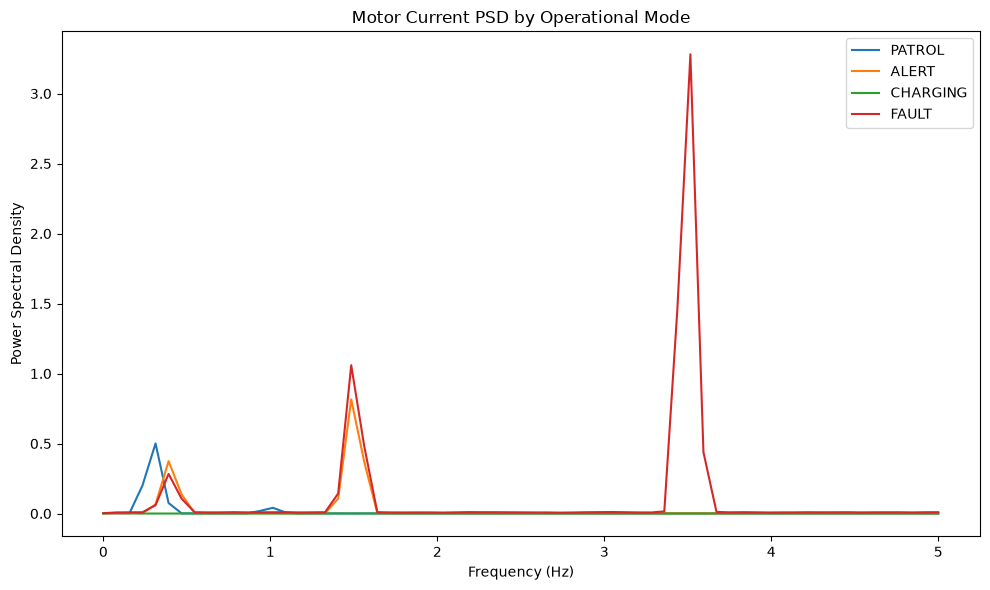

In [53]:
plt.figure(figsize=(10, 6))

for mode in MODES:

    freqs, mean_psd, std_psd = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="motor_current",
        fs=HF_FS,
        nperseg=256
    )

    mask = freqs <= 5

    plt.plot(
        freqs[mask],
        mean_psd[mask],
        label=mode
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Motor Current PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

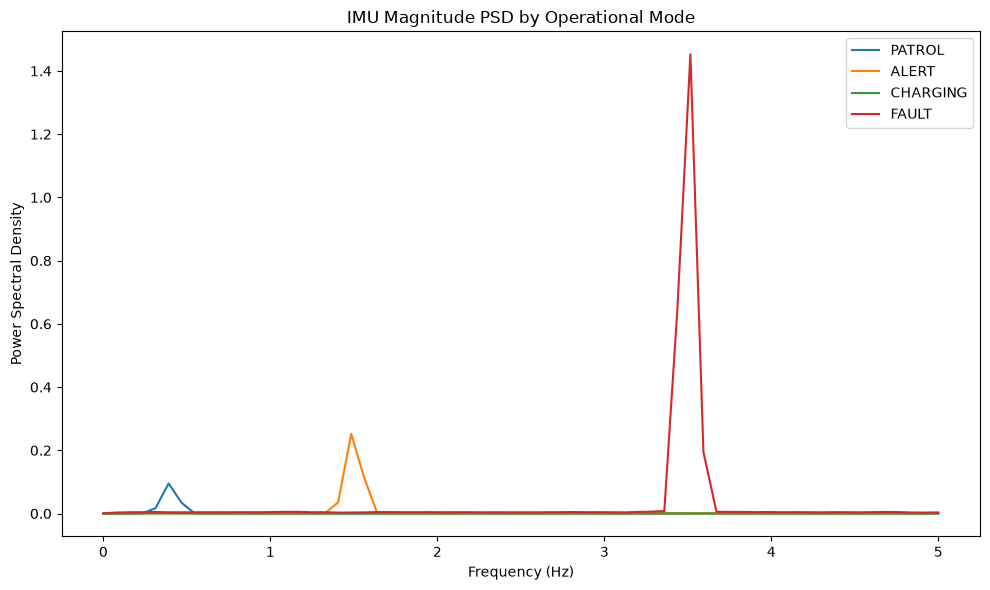

In [54]:
plt.figure(figsize=(10, 6))

for mode in MODES:

    freqs, mean_psd, std_psd = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=HF_FS,
        nperseg=256
    )

    mask = freqs <= 5

    plt.plot(
        freqs[mask],
        mean_psd[mask],
        label=mode
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("IMU Magnitude PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

### PSD Interpretation

The PSD profiles differ clearly across operational modes. For motor current,
PATROL is dominated by low-frequency activity, whereas ALERT shows stronger
medium-frequency components. FAULT exhibits substantially greater spectral
power at higher frequencies, including a pronounced component around the
simulated 3–4 Hz range. CHARGING has very low spectral power, consistent with
minimal motor activity.

A similar pattern appears in the IMU magnitude PSD. FAULT contains much
stronger high-frequency vibration components than the other modes, while
PATROL is primarily characterized by lower-frequency motion. These results
show that frequency-domain features can distinguish normal operating behavior
from abnormal high-frequency activity.

### PSD Spectrograms

In [70]:
from scipy.signal import spectrogram

In [71]:
patrol_signal = hf_df[
    (hf_df["mode"] == "PATROL") &
    (hf_df["window_id"] == 0)
]["motor_current"].values

fault_signal = hf_df[
    (hf_df["mode"] == "FAULT") &
    (hf_df["window_id"] == 0)
]["motor_current"].values

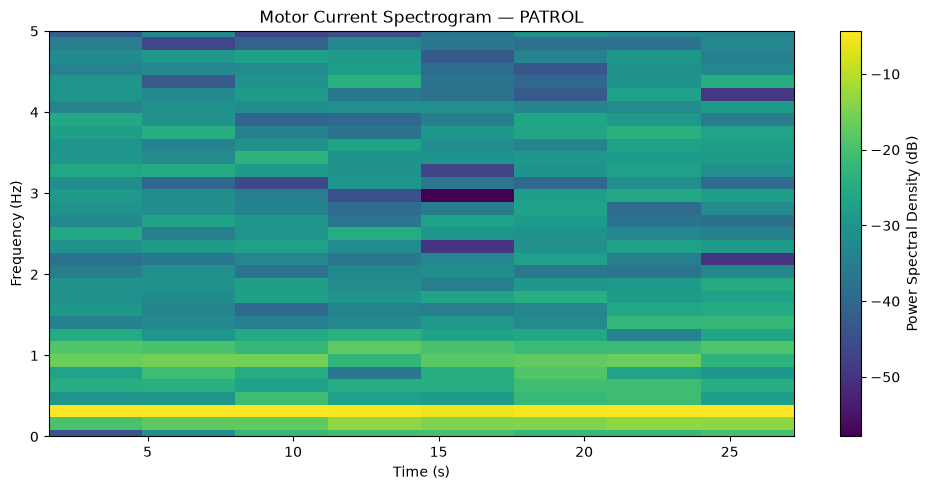

In [72]:
f, t, Sxx = spectrogram(
    patrol_signal,
    fs=HF_FS,
    nperseg=128,
    noverlap=64
)

freq_mask = f <= 5

plt.figure(figsize=(10, 5))

plt.pcolormesh(
    t,
    f[freq_mask],
    10 * np.log10(Sxx[freq_mask] + 1e-12),
    shading="auto"
)

plt.colorbar(label="Power Spectral Density (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Motor Current Spectrogram — PATROL")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

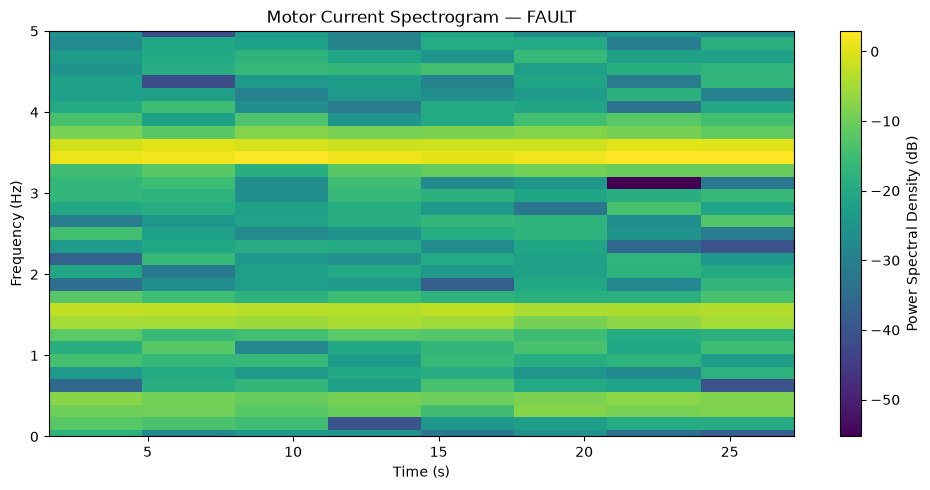

In [73]:
f, t, Sxx = spectrogram(
    fault_signal,
    fs=HF_FS,
    nperseg=128,
    noverlap=64
)

freq_mask = f <= 5

plt.figure(figsize=(10, 5))

plt.pcolormesh(
    t,
    f[freq_mask],
    10 * np.log10(Sxx[freq_mask] + 1e-12),
    shading="auto"
)

plt.colorbar(label="Power Spectral Density (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Motor Current Spectrogram — FAULT")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Spectrogram Interpretation

The spectrograms provide a time-frequency view of the difference between
PATROL and FAULT motor behavior. PATROL shows relatively stable
low-frequency activity throughout the window. In contrast, FAULT contains
persistent higher-frequency energy, particularly in the 2–5 Hz range.

This indicates that the simulated fault condition is not only associated
with greater motor-current variation, but also with a shift of spectral
energy toward higher frequencies. Such time-frequency patterns could provide
useful features for detecting abnormal robot behavior.

## Band Energy Extraction

In [55]:
frequency_bands = {
    "Low": (0.0, 0.5),
    "Medium": (0.5, 2.0),
    "High": (2.0, 5.0)
}

In [56]:
def band_energy(freqs, psd, low, high):
    """
    Integrate PSD within a specified frequency band.
    """

    mask = (freqs >= low) & (freqs <= high)

    return np.trapezoid(
        psd[mask],
        freqs[mask]
    )

In [57]:
motor_band_results = {}

for mode in MODES:

    freqs, mean_psd, _ = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="motor_current",
        fs=HF_FS,
        nperseg=256
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high
        )

    motor_band_results[mode] = energies

motor_band_df = pd.DataFrame(
    motor_band_results
).T

motor_band_df.round(4)

,Low,Medium,High
PATROL,0.0610,0.0063,0.0030
ALERT,0.0403,0.1038,0.0066
CHARGING,0.0006,0.0001,0.0003
FAULT,0.0331,0.1418,0.4292


In [58]:
motor_relative_band_df = motor_band_df.div(
    motor_band_df.sum(axis=1),
    axis=0
)

motor_relative_band_df.round(3)

,Low,Medium,High
PATROL,0.868,0.090,0.043
ALERT,0.267,0.689,0.044
CHARGING,0.584,0.134,0.281
FAULT,0.055,0.235,0.711


In [59]:
motor_relative_band_df.sum(axis=1)

PATROL      1.0
ALERT       1.0
CHARGING    1.0
FAULT       1.0
dtype: float64

### IMU Band Energy

In [60]:
imu_band_results = {}

for mode in MODES:

    freqs, mean_psd, _ = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=HF_FS,
        nperseg=256
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high
        )

    imu_band_results[mode] = energies

imu_band_df = pd.DataFrame(
    imu_band_results
).T

imu_relative_band_df = imu_band_df.div(
    imu_band_df.sum(axis=1),
    axis=0
)

imu_band_df.round(4)

,Low,Medium,High
PATROL,0.0102,0.0005,0.0011
ALERT,0.0005,0.0325,0.0030
CHARGING,0.0000,0.0001,0.0001
FAULT,0.0018,0.0060,0.1912


In [61]:
imu_relative_band_df.round(3)

,Low,Medium,High
PATROL,0.866,0.043,0.091
ALERT,0.013,0.903,0.084
CHARGING,0.089,0.289,0.622
FAULT,0.009,0.030,0.961


### Motor Current Relative Band Energy Heatmap

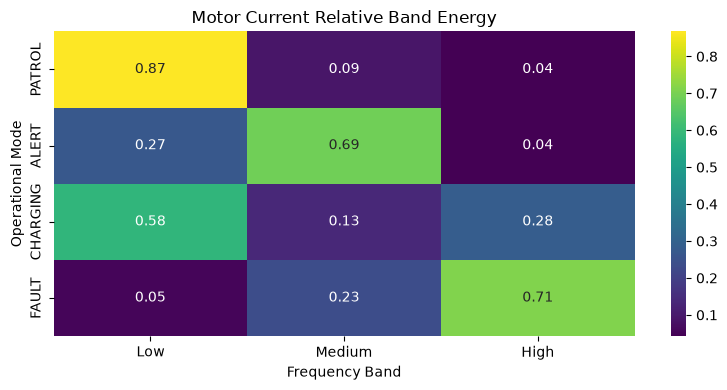

In [62]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    motor_relative_band_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("Motor Current Relative Band Energy")

plt.tight_layout()
plt.show()

### IMU Relative Band Energy Heatmap

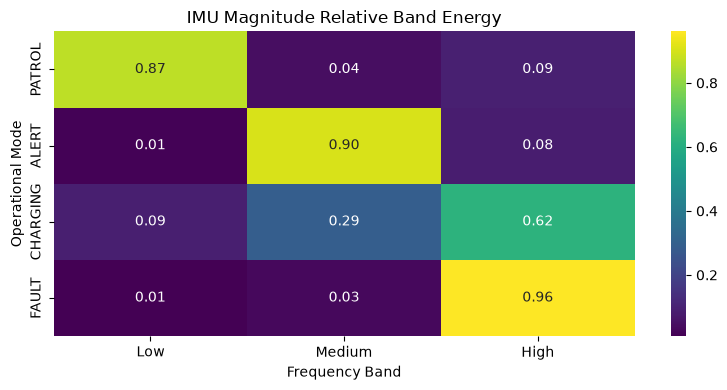

In [63]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    imu_relative_band_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("IMU Magnitude Relative Band Energy")

plt.tight_layout()
plt.show()

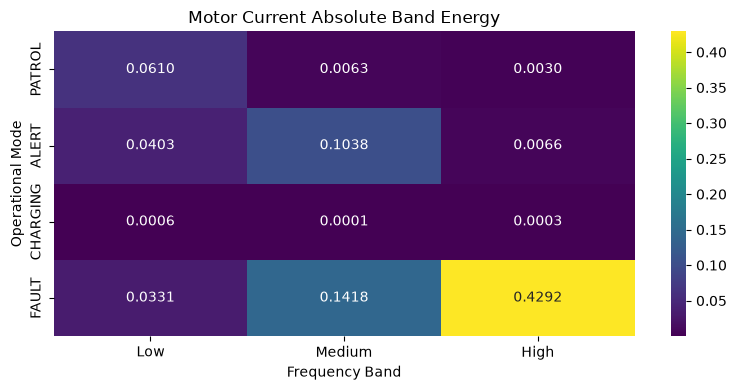

In [64]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    motor_band_df,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("Motor Current Absolute Band Energy")

plt.tight_layout()
plt.show()

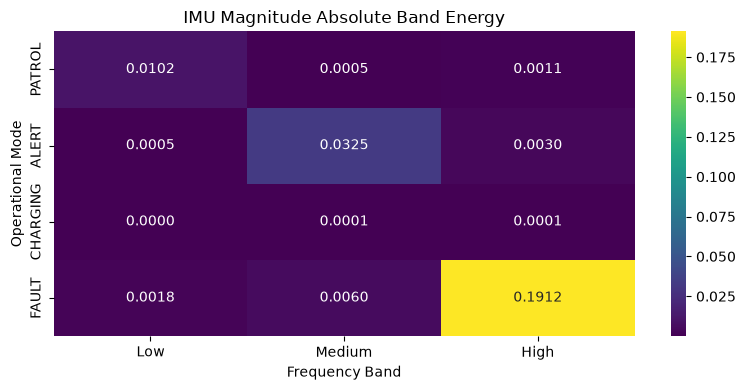

In [65]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    imu_band_df,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("IMU Magnitude Absolute Band Energy")

plt.tight_layout()
plt.show()

### Band Energy per Window

In [80]:
def extract_window_band_energy(
    hf_df,
    signal_col,
    fs=20,
    nperseg=256
):

    results = []

    for (mode, window_id), window_df in hf_df.groupby(
        ["mode", "window_id"]
    ):

        signal = window_df[signal_col].values

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=nperseg
        )

        row = {
            "mode": mode,
            "window_id": window_id,
            "channel": signal_col
        }

        for band_name, (low, high) in frequency_bands.items():

            row[band_name] = band_energy(
                freqs,
                psd,
                low,
                high
            )

        results.append(row)

    return pd.DataFrame(results)

In [81]:
motor_window_energy = extract_window_band_energy(
    hf_df,
    signal_col="motor_current",
    fs=HF_FS
)

motor_window_energy.head()

,mode,window_id,channel,Low,Medium,High
0,ALERT,0,motor_current,0.038437,0.095691,0.007165
1,ALERT,1,motor_current,0.037672,0.097038,0.007073
2,ALERT,2,motor_current,0.043606,0.100037,0.005974
3,ALERT,3,motor_current,0.034116,0.104534,0.006069
4,ALERT,4,motor_current,0.038183,0.105310,0.005743


In [82]:
imu_window_energy = extract_window_band_energy(
    hf_df,
    signal_col="imu_magnitude",
    fs=HF_FS
)

imu_window_energy.head()

,mode,window_id,channel,Low,Medium,High
0,ALERT,0,imu_magnitude,0.000829,0.031059,0.003424
1,ALERT,1,imu_magnitude,0.000570,0.032557,0.002755
2,ALERT,2,imu_magnitude,0.000737,0.032951,0.003478
3,ALERT,3,imu_magnitude,0.000682,0.031765,0.002635
4,ALERT,4,imu_magnitude,0.000460,0.034299,0.003372


In [83]:
def band_mode_correlations(energy_df):

    results = []

    bands = ["Low", "Medium", "High"]

    for mode in MODES:

        mode_binary = (
            energy_df["mode"] == mode
        ).astype(int)

        for band in bands:

            corr = energy_df[band].corr(
                mode_binary
            )

            results.append({
                "mode": mode,
                "band": band,
                "correlation": corr
            })

    return pd.DataFrame(results)

In [84]:
motor_band_corr = band_mode_correlations(
    motor_window_energy
)

motor_band_corr

,mode,band,correlation
0,PATROL,Low,0.715513
1,PATROL,Medium,-0.531695
2,PATROL,High,-0.334000
3,ALERT,Low,0.172047
4,ALERT,Medium,0.382152
5,ALERT,High,-0.322610
6,CHARGING,Low,-0.870293
7,CHARGING,Medium,-0.589438
8,CHARGING,High,-0.342517
9,FAULT,Low,-0.017267


In [85]:
motor_band_corr_matrix = motor_band_corr.pivot(
    index="mode",
    columns="band",
    values="correlation"
)

motor_band_corr_matrix.round(3)

band,High,Low,Medium
mode,,,
ALERT,-0.323,0.172,0.382
CHARGING,-0.343,-0.870,-0.589
FAULT,0.999,-0.017,0.739
PATROL,-0.334,0.716,-0.532


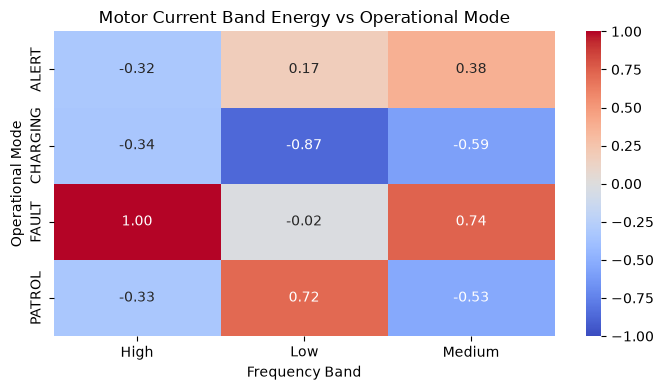

In [86]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    motor_band_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Motor Current Band Energy vs Operational Mode")
plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")

plt.tight_layout()
plt.show()

In [87]:
imu_band_corr = band_mode_correlations(
    imu_window_energy
)

imu_band_corr_matrix = imu_band_corr.pivot(
    index="mode",
    columns="band",
    values="correlation"
)

imu_band_corr_matrix.round(3)

band,High,Low,Medium
mode,,,
ALERT,-0.321,-0.368,0.983
CHARGING,-0.342,-0.429,-0.419
FAULT,0.998,-0.185,-0.164
PATROL,-0.335,0.982,-0.400


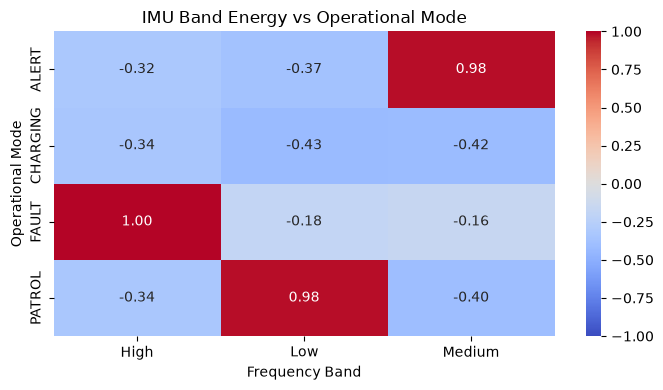

In [88]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    imu_band_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("IMU Band Energy vs Operational Mode")
plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")

plt.tight_layout()
plt.show()

### Band-Energy Correlation Interpretation

Band-energy features show strong mode-specific relationships in the synthetic
sensor data. For motor current, high-frequency energy is almost perfectly
positively associated with FAULT (r = 0.999), while medium-frequency energy
also shows a strong positive association with FAULT (r = 0.739). In contrast,
PATROL is positively associated with low-frequency motor energy (r = 0.716).

The IMU results show an even clearer frequency-to-mode structure. Low-frequency
IMU energy is strongly associated with PATROL (r = 0.982), medium-frequency
energy is strongly associated with ALERT (r = 0.983), and high-frequency
energy is strongly associated with FAULT (r = 0.998).

These results demonstrate that frequency-band energy provides strong
discriminative information about operational state in the synthetic dataset.
In particular, high-frequency motor and IMU energy may serve as useful
features for identifying simulated fault behavior.

Because the frequency components were intentionally embedded during synthetic
data generation, these strong correlations validate the designed simulation
and signal-processing pipeline rather than demonstrating relationships
observed in real Aido Rover telemetry.

## Correlation Analysis

The following analysis returns to the 5-minute fleet-level telemetry dataset.
Pairwise correlations are examined among sensor features to identify
relationships, redundancy, and features that may help distinguish
operational modes.

In [66]:
corr_features = [
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude",
    "motor_current",
    "proximity",
    "rssi",
    "battery_soc",
    "task_success"
]

corr_matrix = df[corr_features].corr()

corr_matrix.round(2)

,accel_x,accel_y,accel_z,imu_magnitude,motor_current,proximity,rssi,battery_soc,task_success
accel_x,1.0,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00
accel_y,-0.0,1.00,-0.01,-0.01,-0.00,-0.00,0.01,-0.00,0.01
accel_z,0.0,-0.01,1.00,0.99,0.01,-0.00,-0.01,-0.00,0.00
imu_magnitude,0.0,-0.01,0.99,1.00,0.06,0.00,-0.04,-0.00,-0.02
motor_current,-0.0,-0.00,0.01,0.06,1.00,0.42,-0.63,-0.04,-0.23
proximity,0.0,-0.00,-0.00,0.00,0.42,1.00,-0.41,-0.03,-0.02
rssi,-0.0,0.01,-0.01,-0.04,-0.63,-0.41,1.00,0.03,0.17
battery_soc,0.0,-0.00,-0.00,-0.00,-0.04,-0.03,0.03,1.00,0.01
task_success,-0.0,0.01,0.00,-0.02,-0.23,-0.02,0.17,0.01,1.00


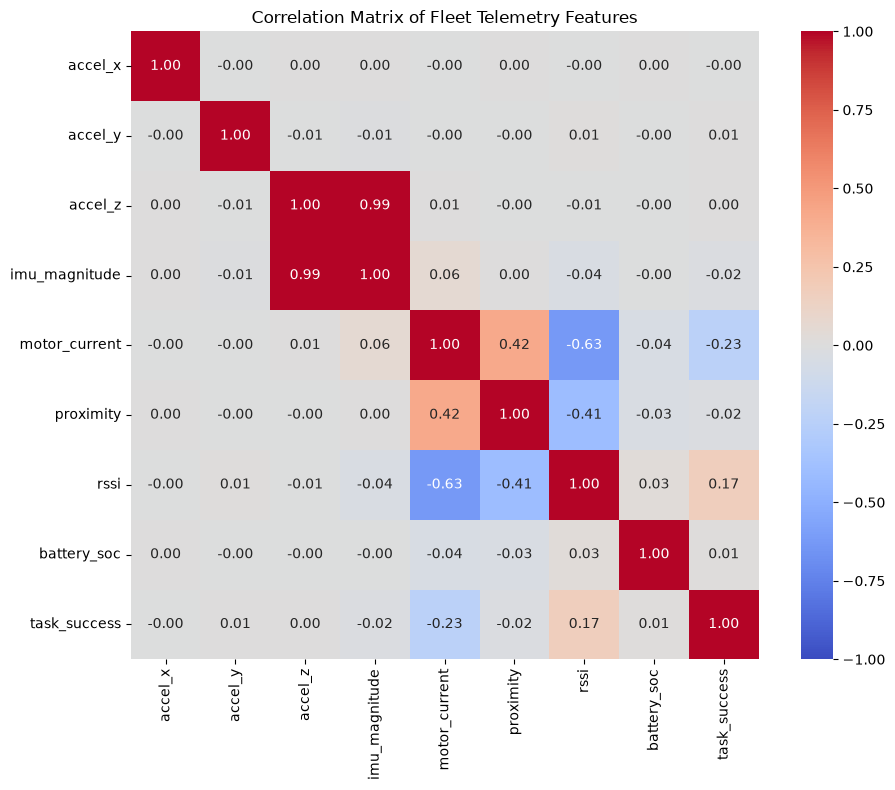

In [67]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix of Fleet Telemetry Features")
plt.tight_layout()
plt.show()

In [68]:
fault_patrol_df = df[
    df["mode"].isin(["PATROL", "FAULT"])
].copy()

fault_patrol_df["is_fault"] = (
    fault_patrol_df["mode"] == "FAULT"
).astype(int)

fault_corr = (
    fault_patrol_df[
        corr_features + ["is_fault"]
    ]
    .corr()["is_fault"]
    .drop("is_fault")
    .sort_values(
        key=abs,
        ascending=False
    )
)

fault_corr.round(3)

motor_current    0.714
task_success    -0.394
rssi            -0.370
proximity       -0.131
imu_magnitude    0.069
accel_z          0.019
accel_y         -0.014
battery_soc     -0.003
accel_x          0.001
Name: is_fault, dtype: float64

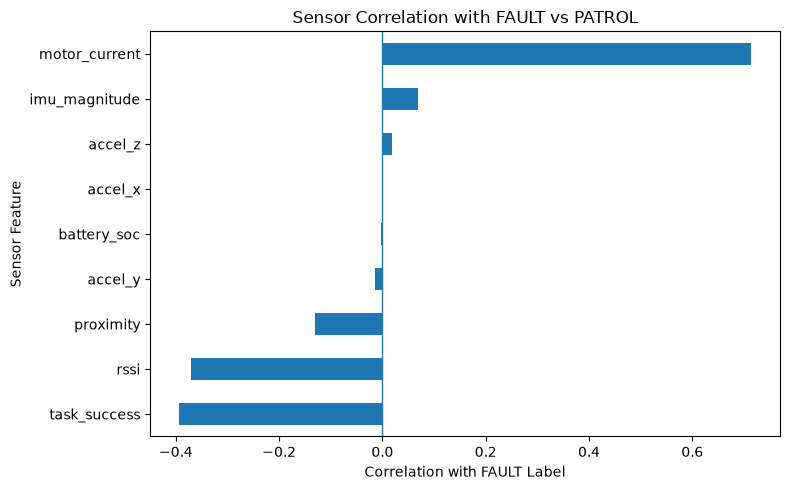

In [69]:
plt.figure(figsize=(8, 5))

fault_corr.sort_values().plot(
    kind="barh"
)

plt.xlabel("Correlation with FAULT Label")
plt.ylabel("Sensor Feature")
plt.title("Sensor Correlation with FAULT vs PATROL")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [89]:
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

corr_pairs["Absolute Correlation"] = (
    corr_pairs["Correlation"].abs()
)

corr_pairs.head()

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,accel_x,accel_x,NaN,NaN
1,accel_x,accel_y,-0.004744,0.004744
2,accel_x,accel_z,0.002753,0.002753
3,accel_x,imu_magnitude,0.002373,0.002373
4,accel_x,motor_current,-0.001240,0.001240


In [90]:
most_correlated = corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
).head(2)

most_correlated

,Feature 1,Feature 2,Correlation,Absolute Correlation
21,accel_z,imu_magnitude,0.994767,0.994767
42,motor_current,rssi,-0.627983,0.627983


In [91]:
least_correlated = corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=True
).head(2)

least_correlated

,Feature 1,Feature 2,Correlation,Absolute Correlation
26,accel_z,task_success,0.000296,0.000296
8,accel_x,task_success,-0.000876,0.000876


### Correlation Interpretation

The two strongest cross-channel relationships were:

1. **Acceleration Z vs. IMU magnitude (r = 0.995)**  
   These features are almost perfectly positively correlated. IMU magnitude is computed from the three acceleration axes, and the z-axis contains the dominant gravitational component (~9.81 m/s²). As a result, variations in `accel_z` strongly influence the overall IMU magnitude.

2. **Motor current vs. RSSI (r = -0.628)**  
   Motor current and RSSI show a moderately strong negative correlation. In the synthetic operational design, abnormal or high-load states such as FAULT tend to have higher motor current and weaker RSSI. Therefore, this relationship is likely driven by differences between operational modes rather than a direct causal relationship between motor current and wireless signal strength.

The two weakest cross-channel relationships were:

1. **Acceleration Z vs. task success (r ≈ 0.0003)**
2. **Acceleration X vs. task success (r ≈ -0.0009)**

Both correlations are effectively zero. This indicates that instantaneous acceleration along an individual axis provides little direct information about whether a task succeeds. Task success is more strongly associated with the robot's overall operational condition than with small fluctuations in individual acceleration axes.